In [62]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

df = pd.read_csv("model_accuracy_latency.csv")
df

,model_name,avg_inference_time,val_accuracy
0,EfficientNet-B2,94.88,94.63
1,GhostNet-100,29.82,94.63
2,RegNetY-008,38.98,94.63
3,MobileNetV2-100,24.88,95.19
4,MobileNetV2-140,30.23,95.00


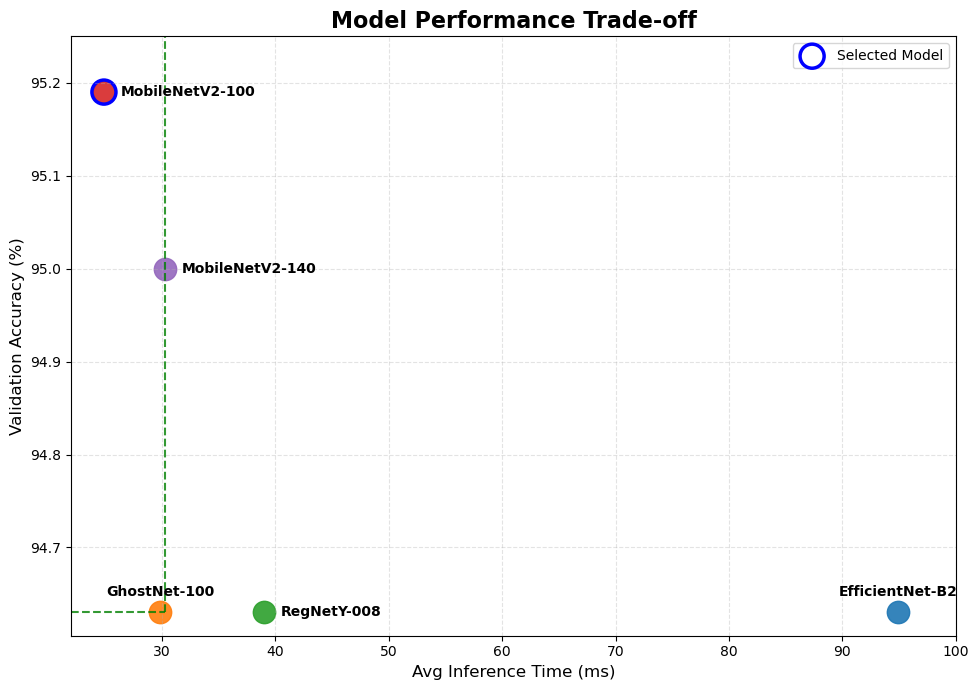

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# df columns expected: model_name, avg_inference_time, val_accuracy
# Example: selected model to circle
selected_model = "MobileNetV2-100"

x = df["avg_inference_time"].values
y = df["val_accuracy"].values
labels = df["model_name"].values

# Quadrant split (use median like the 2nd image style)

plt.figure(figsize=(10, 7))

# Main scatter
cmap = plt.get_cmap("tab10")

for i, (xi, yi, name) in enumerate(zip(x, y, labels)):
    plt.scatter(xi, yi, s=260, alpha=0.9, color=cmap(i % 10))

# Labels ABOVE points (replace your current labeling loop with this)
right_side = {"MobileNetV2-100", "RegNetY-008", "MobileNetV2-140"}

for xi, yi, name in zip(x, y, labels):
    if name in right_side:
        plt.annotate(
            name, (xi, yi),
            textcoords="offset points",
            xytext=(12, 0),     # move text to the right
            ha="left",
            va="center",
            fontsize=10,
            weight="bold"
        )
    else:
        plt.annotate(
            name, (xi, yi),
            textcoords="offset points",
            xytext=(0, 10),     # move text above
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold"
        )


xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
x_thr = np.median(x)
y_thr = np.median(y)

plt.plot([22, x_thr], [y_thr, y_thr], "--", color="green", linewidth=1.5, alpha=0.8)  # short horizontal
plt.plot([x_thr, x_thr], [y_thr, 95.25], "--", color="green", linewidth=1.5, alpha=0.8)  # short vertical


# Highlight selected model with a red ring (like your 2nd image)
sel = df[df["model_name"] == selected_model]
if not sel.empty:
    plt.scatter(
        sel["avg_inference_time"],
        sel["val_accuracy"],
        s=300,
        facecolors="none",
        edgecolors="blue",
        linewidths=2.5,
        label="Selected Model"
    )

# Styling to look similar
plt.title("Model Performance Trade-off", fontsize=16, weight="bold")
plt.xlabel("Avg Inference Time (ms)", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.xlim(22, 100)
plt.ylim(94.605, 95.25)
plt.show()


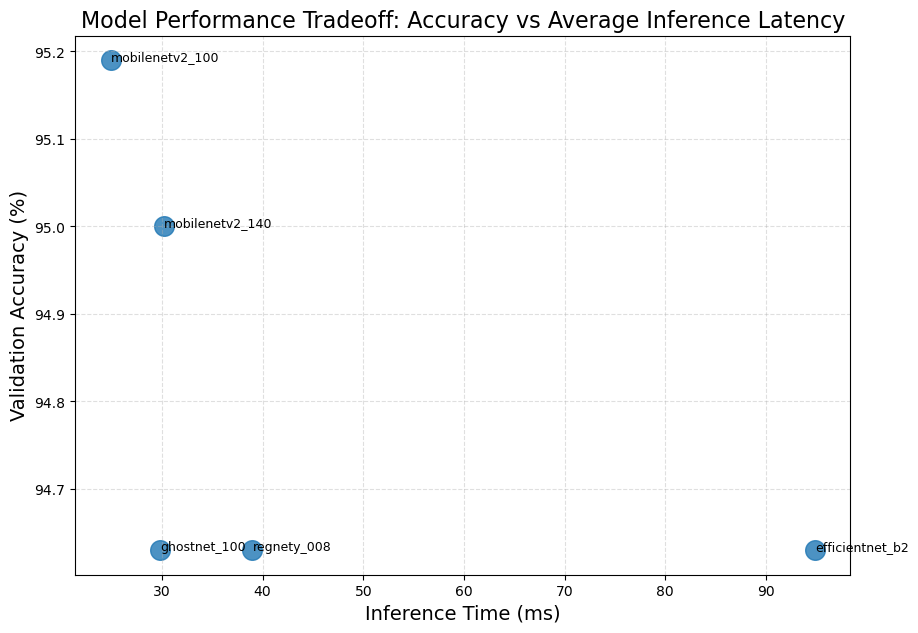

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# scatter plot
plt.scatter(
    df["avg_inference_time"], 
    df["val_accuracy"], 
    s=200, 
    alpha=0.8
)

# label each point
for i in range(len(df)):
    plt.text(
        df["avg_inference_time"][i], 
        df["val_accuracy"][i], 
        df["model_name"][i],
        fontsize=9
    )

plt.xlabel("Inference Time (ms)", fontsize=14)
plt.ylabel("Validation Accuracy (%)", fontsize=14)
plt.title("Model Performance Tradeoff: Accuracy vs Average Inference Latency", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

<Axes: xlabel='avg_inference_time', ylabel='val_accuracy'>

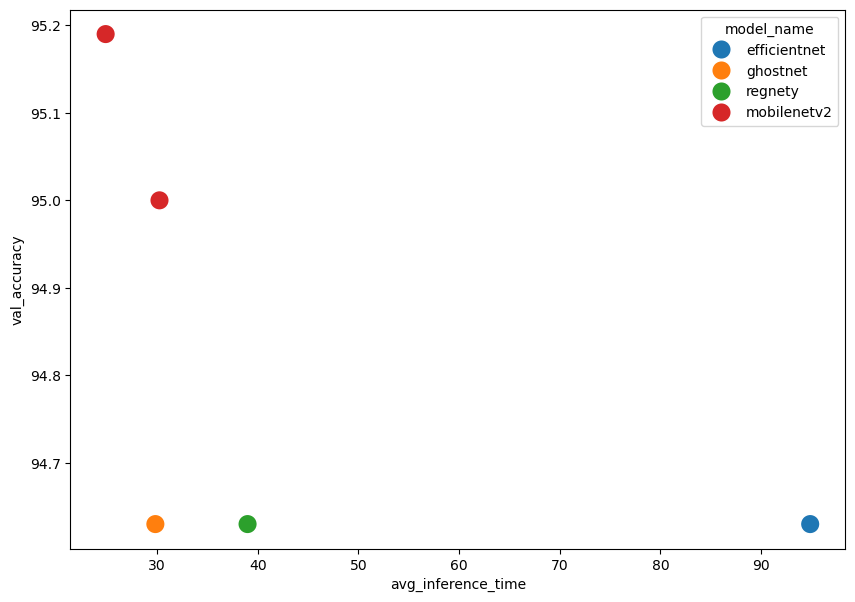

In [6]:
import seaborn as sns

families = df["model_name"].apply(lambda x: x.split("_")[0])

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x="avg_inference_time",
    y="val_accuracy",
    hue=families,
    s=200
)
